In [2]:
import numpy as np
inputs = [0, -2, -1, 2.4, 5, -0.1, 0.01]
output = np.maximum(0, inputs)
print(output)

[0.   0.   0.   2.4  5.   0.   0.01]


In [3]:
class Activation_ReLU:
    def forward(self, inputs):
        self.output = np.maximum(0, inputs)
        return self.output

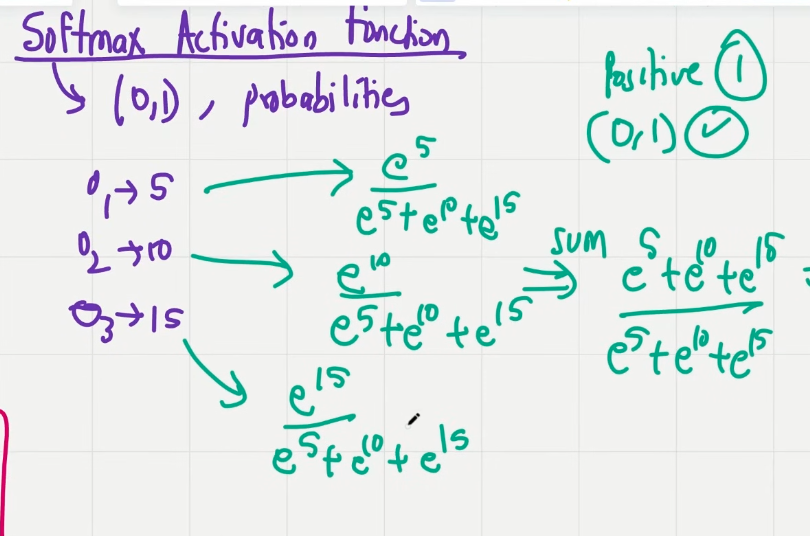

In [11]:
inputs = np.random.randn(3, 4)
#print(inputs)

exp_vals = np.exp(inputs - np.max(inputs, axis=1, keepdims=True))
#print(exp_vals)

prob = exp_vals/np.sum(exp_vals, axis=1, keepdims=True)
print(prob)
np.sum(prob, axis=1, keepdims=True)


[[0.4711022  0.03114218 0.06937919 0.42837643]
 [0.0368286  0.49024119 0.4546557  0.01827452]
 [0.10215069 0.08834767 0.22026446 0.58923718]]


array([[1.],
       [1.],
       [1.]])

In [18]:
class Activation_Softmax:

    def forward(self, inputs):
        self.input = inputs
        exp_vals = np.exp(inputs - np.max(inputs, axis=1, keepdims=True))
        prob = exp_vals/np.sum(exp_vals, axis=1, keepdims=True)
        self.output = prob
        #return prob

In [23]:
import numpy as np
import nnfs 
from nnfs.datasets import spiral_data
nnfs.init()

#Dense layer
class Layer_Dense:
    #layer init
    def __init__(self, n_inputs, n_neurons):
        self.weights = 0.01 * np.random.randn(n_inputs, n_neurons) #not n_neurons x n_inputs --> 
        self.biases = np.zeros((1, n_neurons))                     #to avoid the transpose in dot products

    #forward pass
    def forward(self, inputs):
        self.output = np.dot(inputs, self.weights) + self.biases
        return self.output                                        

#Create dataset
#X, y = spiral_data(samples=100, classes=3)
X = np.random.randn(300, 2)

dense1 = Layer_Dense(2, 3)
activation1 = Activation_ReLU()

dense2 = Layer_Dense(3, 3)
activation2  = Activation_Softmax()

dense1.forward(X)
activation1.forward(dense1.output)

dense2.forward(activation1.output)
activation2.forward(dense2.output)

print(activation2.output[:5])

print("X shape:", X.shape)
print("dense2 weights shape:", dense2.weights.shape)
print("final output shape:", activation2.output.shape)

[[0.33333772 0.33332986 0.3333324 ]
 [0.33333334 0.33333334 0.33333334]
 [0.33338806 0.33329022 0.33332172]
 [0.3333488  0.33332112 0.33333   ]
 [0.33333713 0.3333238  0.33333907]]
X shape: (300, 2)
dense2 weights shape: (3, 3)
final output shape: (300, 3)
